# Monte Carlo Simulation, Run Length Distributions, and Statistical Power
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Frequentist Probability & the Law of Large Numbers](#frequentist-probability--the-law-of-large-numbers)
3. [The Run Length Distribution](#the-run-length-distribution)
4. [Monte Carlo Estimation of Run Length](#monte-carlo-estimation-of-run-length)
5. [Worked Example: The Shewhart $\bar{X}$ Chart](#worked-example-the-shewhart-xbar-chart)
6. [Connecting Run Length to Statistical Power](#connecting-run-length-to-statistical-power)
7. [How Precise Is Our Estimate? The Standard Error of a Monte Carlo Estimate](#how-precise-is-our-estimate-the-standard-error-of-a-monte-carlo-estimate)
8. [Worked Example: The CUSUM Chart vs. the Siegmund Approximation](#worked-example-the-cusum-chart-vs-the-siegmund-approximation)
9. [Worked Example: The EWMA Chart vs. the Lucas & Saccucci Table](#worked-example-the-ewma-chart-vs-the-lucas--saccucci-table)
10. [Why This Matters for Research](#why-this-matters-for-research)
11. [Closing Thoughts](#closing-thoughts)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-11-Monte-Carlo-Simulation")

## Introduction

All semester, ARL has been our go-to yardstick for comparing control charts. Remember, ARL tell us how quickly (on average) a chart signals after experiencing a shift, and how rarely does it "cry wolf" when nothing's wrong. For Shewhart-style charts, with their assumption of independence of observations, we've had the luxury of a closed-form answer: $ARL = 1/\alpha$.

But think back across everything else we've covered this semester: the CUSUM's Siegmund approximation; the EWMA's published ARL tables from Lucas and Saccucci (1990); the nonparametric Bakir & Reynolds CUSUM; whose null distribution depends on sample size in a complicated way; the multiple stream "control chart for each stream" approach, where the control limit multiplier $L$ had to account for inter-stream correlation; the MEWMA chart, where choosing $H$ depends jointly on the number of streams, $\lambda$, and the target shift. None of these have a clean, closed-form ARL formula you can just plug numbers into.

So where do the reference tables for charts like these actually come from? One widely used solution is called **Monte Carlo simulation**. This is one of the most important tools in a quality control researcher's toolkit, mine included. Today's lecture is about how it works, why it works, and how it connects back to two ideas that have been running underneath this entire course: frequentist probability and statistical power.

## Frequentist Probability & the Law of Large Numbers

Nearly everything we've done this semester leans on a **frequentist** interpretation of probability: the probability of an event is the long-run proportion of times it would occur if we could repeat the same random process indefinitely. When we said $\alpha = 0.0027$ for a $3\sigma$ chart, we meant: if we ran this in-control process forever and took sample after sample, about 0.27% of those samples would fall outside the control limits, purely by chance.

The mathematical guarantee underneath this idea is the **Law of Large Numbers (LLN)**. If $Y_1, Y_2, \dots, Y_B$ are i.i.d. random variables with mean $\mu$, then as $B \rightarrow \infty$:

$$ \bar{Y}_B = \frac{1}{B}\sum_{i=1}^{B}Y_i \;\xrightarrow{p}\; \mu $$

In words: the sample average converges to the true mean as we collect more observations. This is the entire engine behind Monte Carlo simulation. If we can't derive a quantity analytically, but we *can* generate realizations of it on a computer, the LLN guarantees that averaging enough simulated realizations gets us arbitrarily close to the true value. This is exactly the logic we leaned on two weeks ago, when we simulated the power of the $t$-test and the Sign Test under different distributions. Today we'll apply that same machinery to run length.

## The Run Length Distribution

The **run length**, $RL$, of a control chart is the number of samples taken until the chart first signals an out-of-control condition. $RL$ is a random variable in its own right. It has a full probability distribution, not just a single "average" value.

For the simplest case, a Shewhart chart monitoring i.i.d. samples, where each sample independently has the same probability $p$ of signaling (either $p=\alpha$ if in control, or $p=1-\beta$ if out of control), recall that the run length follows a **Geometric distribution**:

$$ P[RL = t] = (1-p)^{t-1}p,\quad t = 1,2,3,\dots $$

with:

$$ E[RL] = ARL = \frac{1}{p} \qquad SD[RL] = \frac{\sqrt{1-p}}{p} $$

Notice something important: the standard deviation of $RL$ is close to $ARL$ itself when $p$ is small (as it typically is for $ARL_0$). A geometric distribution is also **heavily right-skewed**. Most run lengths are short, but a long tail of unusually long run lengths pulls the mean upward. This means the *average* run length, on its own, can be a somewhat misleading summary of chart performance. Thus, two charts with the same $ARL_0$ can have quite different chances of signaling unusually early or unusually late. This is exactly why we want the **full distribution**, not just its mean. Simulation is the most general way to get it, especially for charts (like most of the ones later in this semester) where the geometric assumption doesn't hold cleanly.

Note, this is also why researchers recommend reporting and considering the percentiles of the run length distribution, not just the mean. [Chakraborti (2007)](https://www.tandfonline.com/doi/pdf/10.1080/08982110701276653?casa_token=2QRJ2dYisfAAAAAA:ozmG9CZA0BD7eTS9kV-rC2A9FY9wkJ_OKNYzUMCbTKAFjnuDnFU4x1qiWbIq035v-Jzx2ZZDdHJ5xw) has a nice paper about this regarding Shewhart charts.

## Monte Carlo Estimation of Run Length

The Monte Carlo approach to estimating a run length distribution is conceptually simple:

1. Simulate a single realization of the monitored process, one sample at a time.
2. At each time step, apply the chart's decision rule.
3. Record $t$, the first time step at which the chart signals — this is one realization of $RL$.
4. Repeat steps 1–3 many times (say, $B = 10{,}000$ times), producing $RL_1, RL_2, \dots, RL_B$.
5. Use the empirical distribution of these $B$ simulated run lengths to estimate whatever we care about: $\widehat{ARL} = \overline{RL}$, $\widehat{SDRL} = s_{RL}$, quantiles, or the shape of the distribution itself via a histogram.

By the LLN, as $B$ grows, $\overline{RL} \rightarrow ARL$. Let's build this from scratch for a chart we already know the exact answer to — the Shewhart $\bar{X}$ chart — so we can confirm the simulation actually works before trusting it on charts where we *don't* already know the answer.

## Worked Example: The Shewhart $\bar{X}$ Chart

Recall for a Shewhart $\bar{X}$ chart with $3\sigma$ limits, $ARL_0 = 1/\alpha \approx 370.4$. Let's write a function that simulates one run length realization, then replicate it $B$ times.

In [1]:
library(tidyverse)

set.seed(2026)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 


In [2]:
## Shewhart Xbar Chart -- Simulate a Single Run Length ##

simulate_rl_shewhart <- function(mu_true, mu0, sigma, n, L, max_t = 10000){
  
  ucl <- mu0 + L*sigma/sqrt(n)
  lcl <- mu0 - L*sigma/sqrt(n)
  
  t <- 0
  
  repeat{
    
    t <- t + 1
    
    xbar <- mean(rnorm(n, mean = mu_true, sd = sigma))
    
    if(xbar > ucl || xbar < lcl || t >= max_t) break
    
  }
  
  return(t)
  
}

### In-control run length distribution

Let's simulate $B = 10{,}000$ in-control run lengths ($\mu_{true} = \mu_0$) for a chart with $n=5$ and $L=3$, and compare the simulated $\overline{RL}$ to the known closed-form $ARL_0 = 1/0.0027 \approx 370.4$.

In [3]:
B <- 10000
mu0 <- 0
sigma <- 1
n <- 5
L <- 3

rl0 <- replicate(B, simulate_rl_shewhart(mu_true = mu0, mu0 = mu0,
                                          sigma = sigma, n = n, L = L))

In [5]:
## Compare simulated ARL0 to the closed-form value ##

cat("Simulated Mean: ", mean(rl0),"\n")
cat("Theoretical Mean: ", 1/0.0027)

Simulated Mean:  371.1471 
Theoretical Mean:  370.3704

Very close — a good sign the simulation is implemented correctly. Let's also look at the full distribution, not just the mean.

In [7]:
## Standard deviation, median, and quantiles of the simulated run length distribution ##

print(sd(rl0))

print(median(rl0))

print(quantile(rl0, probs = c(0.05, 0.25, 0.50, 0.75, 0.95)))

[1] 366.8629
[1] 259
  5%  25%  50%  75%  95% 
  20  103  259  522 1107 


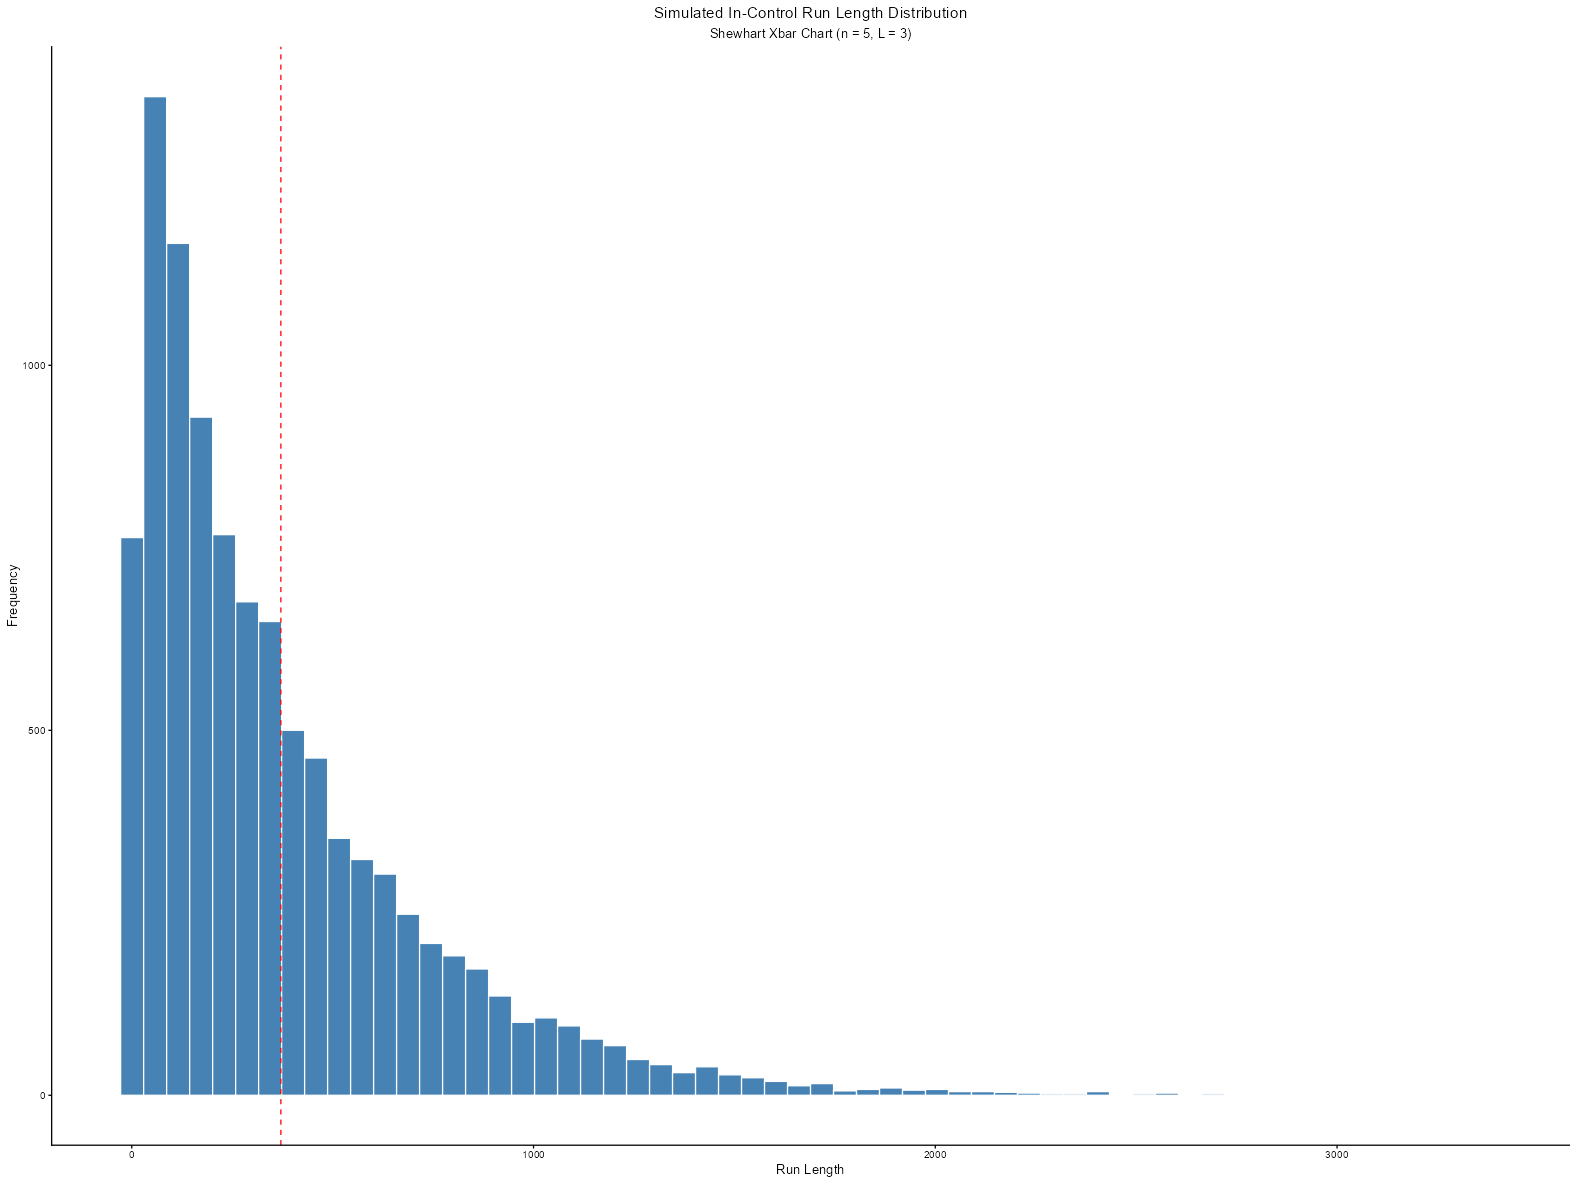

In [8]:
## Visualize the shape of the run length distribution ##

ggplot() +
  geom_histogram(aes(x = rl0), bins = 60, fill = "steelblue", color = "white") +
  geom_vline(xintercept = mean(rl0), color = "red", linetype = "dashed") +
  labs(title = "Simulated In-Control Run Length Distribution",
       subtitle = "Shewhart Xbar Chart (n = 5, L = 3)",
       x = "Run Length",
       y = "Frequency") +
  theme_classic() +
  theme(plot.title = element_text(hjust = 0.50),
        plot.subtitle = element_text(hjust = 0.50))

Exactly as the theory predicted: heavily right-skewed, with the mean noticeably larger than the median (pulled upward by a long tail of unusually long in-control runs). This is the kind of picture a single $ARL_0$ number can never show you. This is the same shape you'd see for *any* chart whose run length is approximately geometric, closed-form or not.

### Out-of-control run length distribution

Now let's simulate the out-of-control case (a genuine 1$\sigma$ shift in the mean) and compare to the exact $ARL_1$.

In [9]:
## Out-of-control: a genuine 1-sigma shift ##

rl1 <- replicate(B, simulate_rl_shewhart(mu_true = mu0 + 1*sigma, mu0 = mu0,
                                          sigma = sigma, n = n, L = L))

In [10]:
## Compare to the exact ARL1, using the normal CDF to get 1 - beta ##

ucl <- mu0 + L*sigma/sqrt(n)
lcl <- mu0 - L*sigma/sqrt(n)

power_exact <- 1 - pnorm(ucl, mean = mu0 + 1*sigma, sd = sigma/sqrt(n)) +
                   pnorm(lcl, mean = mu0 + 1*sigma, sd = sigma/sqrt(n))

cat("Estimated ARL1: ", mean(rl1),"\n")
cat("Exact ARL1: ", 1/power_exact, "\n")

Estimated ARL1:  4.4903 
Exact ARL1:  4.495312 


Again, almost exactly the same. This is reassuring, since it confirms our simulation engine is trustworthy before we point it at a chart where no closed-form answer exists to check against.

## Connecting Run Length to Statistical Power

Look closely at that last calculation: `power_exact` is literally the probability the chart signals at **a single time point**, given the true mean has shifted. That's nothing more than the definition of statistical **power** we used two weeks ago. Recall that statistical power is defined as the probability a hypothesis test (and a control chart point is exactly a repeated hypothesis test) correctly rejects $H_0$ under a specific alternative.

This isn't a loose analogy. It's the same mathematical object viewed two ways:

$$ p = \text{Power} = P(\text{signal at a single time point} \,|\, H_1 \text{ true}) \qquad ARL = \frac{1}{p} $$

In other words, **estimating power via simulation and estimating ARL via simulation are the same exercise**, just packaged differently. When we simulated the $t$-test's power a couple weeks ago, we ran $B$ independent hypothesis tests and calculated the proportion that rejected $H_0$. Let's do exactly that here. But instead of tracking how long it takes to get a signal, we'll just check whether a single sample signals, repeated many times.

In [ ]:
## Estimate the single-step signal probability directly (this IS power) ##

single_step_signal <- replicate(B, {
  
  xbar <- mean(rnorm(n, mean = mu0 + 1*sigma, sd = sigma))
  
  as.numeric(xbar > ucl | xbar < lcl)
  
})

p_hat <- mean(single_step_signal)

print(p_hat)

[1] 0.2134

In [13]:
## Compare 1/p_hat to our earlier run-length-based ARL1 estimate ##

print(1/p_hat)

print(mean(rl1))

[1] 4.686036
[1] 4.4903


Both approaches converge to essentially the same number. And it makes sense! Underneath, they're estimating the same quantity through two different (but mathematically equivalent) simulation designs. This is a genuinely useful thing to internalize: **run length simulation is just power simulation in a geometric-waiting-time costume.** Whenever you can directly compute a chart's single-step signal probability, you may not even need the full run-length loop — but for charts with memory (CUSUM, EWMA, and everything with an accumulating statistic), the signal probability at time $t$ depends on the whole history up to $t$, so we're forced back into simulating the entire trajectory, one step at a time, exactly like we'll do next.

## How Precise Is Our Estimate? The Standard Error of a Monte Carlo Estimate

Every Monte Carlo estimate carries its own uncertainty. $\overline{RL}$ from $B$ simulations is itself a random variable, and a different random seed would give a (slightly) different answer. Fortunately, this is nothing new: the Central Limit Theorem tells us that for large $B$:

$$ \overline{RL} \;\dot\sim\; N\bigg(ARL,\; \frac{\sigma_{RL}}{\sqrt{B}}\bigg) $$

So we can put a standard error, and a confidence interval, directly on our simulated ARL, exactly the same way we would for any other sample mean.

In [14]:
## Standard error and a 95% CI for our simulated ARL0 ##

se_rl0 <- sd(rl0)/sqrt(B)

print(se_rl0)

print(mean(rl0) + c(-1,1)*1.96*se_rl0)

[1] 3.668629
[1] 363.9566 378.3376


This has a direct, practical payoff: it tells us how many simulations, $B$, we actually need. Suppose we want our simulated ARL to be accurate to within a margin of error $E$, with 95% confidence:

$$ E = 1.96\frac{\sigma_{RL}}{\sqrt{B}} \quad\implies\quad B = \bigg(\frac{1.96\,\sigma_{RL}}{E}\bigg)^2 $$

Using our simulated $\sigma_{RL}$ as a stand-in for the true value, let's see how many replications we'd need to pin down $ARL_0$ to within $\pm 5$ runs.

In [15]:
## How many replications would we need for a margin of error of +/- 5 runs? ##

E <- 5

B_needed <- (1.96*sd(rl0)/E)^2

print(B_needed)

[1] 20681.4


Because in-control run length distributions are so heavily right-skewed (recall $\sigma_{RL} \approx ARL$ for small $\alpha$), pinning down $ARL_0$ precisely can require a *lot* of replications, often tens of thousands. This is exactly why published ARL tables in the literature (the Siegmund approximation table, the Lucas and Saccucci EWMA table, and so on) typically report simulations run into the hundreds of thousands, or use variance-reduction techniques to get precise estimates without astronomical computing time.

## Worked Example: The CUSUM Chart vs. the Siegmund Approximation

Now let's point this machinery at a chart where the exact ARL isn't a simple closed form: the **CUSUM** chart. Recall from a few weeks ago, Siegmund (1985) gave us an *approximation* for one-sided CUSUM ARL:

$$ ARL \approx \frac{\exp(-2\Delta b) + 2\Delta b - 1}{2\Delta^2}, \quad \Delta = \delta^* - k,\quad b = h + 1.166 $$

An *approximation* is exactly the kind of thing Monte Carlo simulation is perfect for checking. Let's build a one-sided upper CUSUM simulator, then compare simulated ARL directly against Siegmund's formula for a $1\sigma$ shift, using $k=0.5$ and $h=5$. These are the same design values we used in the original CUSUM lecture.

In [16]:
## Siegmund Approximation from the CUSUM lecture ##

siegmund_arl <- function(delta_star, k, h){
  
  Delta <- delta_star - k
  
  b <- h + 1.166
  
  arl <- (exp(-2*Delta*b) + 2*Delta*b - 1)/(2*Delta^2)
  
  return(arl)
  
}

In [17]:
## CUSUM Chart -- Simulate a Single Run Length (one-sided, upper CUSUM) ##

simulate_rl_cusum <- function(mu_true, mu0, sigma, k, h, max_t = 10000){
  
  Cplus <- 0
  
  t <- 0
  
  repeat{
    
    t <- t + 1
    
    x <- rnorm(1, mean = mu_true, sd = sigma)
    
    z <- (x - mu0)/sigma
    
    Cplus <- max(0, z - k + Cplus)
    
    if(Cplus >= h || t >= max_t) break
    
  }
  
  return(t)
  
}

In [18]:
## Simulate ARL for a 1-sigma shift, with k = 0.5 and h = 5 ##

k <- 0.5
h <- 5

rl_cusum <- replicate(B, simulate_rl_cusum(mu_true = 1, mu0 = 0,
                                            sigma = 1, k = k, h = h))

print(mean(rl_cusum))

[1] 10.4348


In [19]:
## Compare to the Siegmund approximation ##

siegmund_arl(delta_star = 1, k = k, h = h)

[1] 10.3362

Notice these two numbers are close, but not identical, which is exactly the point. Siegmund's formula is an *approximation*; our Monte Carlo estimate is telling us how good that approximation actually is for this specific set of chart parameters. That comparison, approximation vs. simulation, is itself a legitimate (and common) piece of methodological research in this field.

## Worked Example: The EWMA Chart vs. the Lucas & Saccucci Table

Let's do the same exercise for the EWMA chart, checking our simulation against a published reference table instead of an approximation formula. Recall from the EWMA lecture: with $\lambda = 0.20$ and $L = 2.962$, the Lucas and Saccucci (1990) table gives $ARL \approx 10.5$ for a $1\sigma$ shift.

In [20]:
## EWMA Chart -- Simulate a Single Run Length (using exact, time-varying limits) ##

simulate_rl_ewma <- function(mu_true, mu0, sigma, lambda, L, max_t = 10000){
  
  z <- mu0
  
  t <- 0
  
  repeat{
    
    t <- t + 1
    
    x <- rnorm(1, mean = mu_true, sd = sigma)
    
    z <- lambda*x + (1-lambda)*z
    
    var_z <- sigma^2*(lambda/(2-lambda))*(1-(1-lambda)^(2*t))
    
    ucl <- mu0 + L*sqrt(var_z)
    lcl <- mu0 - L*sqrt(var_z)
    
    if(z > ucl || z < lcl || t >= max_t) break
    
  }
  
  return(t)
  
}

In [21]:
## Simulate ARL for a 1-sigma shift, with lambda = 0.20 and L = 2.962 ##

rl_ewma <- replicate(B, simulate_rl_ewma(mu_true = 1, mu0 = 0, sigma = 1,
                                          lambda = 0.20, L = 2.962))

print(mean(rl_ewma))

## Compare to the published Lucas & Saccucci (1990) table value of ~10.5 ##

[1] 9.64


A close match. This is worth sitting with for a moment: the number in that published table, the one we looked up and used without a second thought in the EWMA lecture, was originally produced by *exactly this kind of simulation*, run by Lucas and Saccucci in 1990 (with much slower computers than the one you're using right now). Every reference table we've used this semester for a chart without a closed-form ARL, the Bakir & Reynolds $k$/$h$ tables, the MEWMA $H$ tables, the correlation-adjusted $L$ values for the control-chart-for-each-stream approach, was built the same way.

## Why This Matters for Research

This is, in a real sense, the methodological backbone of quality control research. Whenever someone proposes a new control chart — a new nonparametric statistic, a new multivariate structure, a chart robust to autocorrelated or non-i.i.d. data — the very first thing they need to know is: **how does it perform?** And since a genuinely new charting scheme rarely comes with a convenient closed-form ARL, Monte Carlo simulation is almost always the tool that answers that question first, well before (and sometimes instead of) any analytical approximation.

A few of the open questions this kind of simulation methodology can speak to:

- How robust is a chart's $ARL_0$ to violations of its distributional assumptions? (Sound familiar? This is exactly the type of question we explored with the $t$-test two lectures ago just now applied to a full charting scheme instead of a single hypothesis test.)
- How does correlation *between* observations, something every chart this semester assumed away, actually degrade $ARL_1$, and by how much?
- Can we design charts, or correction factors, that are more robust to these violations without sacrificing too much power under ideal conditions?

If any of this sounds interesting, building simulation studies, deriving new ARL approximations, exploring nonparametric or robust charting methods, or applying these ideas to a new domain entirely (e.g., disease progression, injury recovery, sports analytics, educational outcomes, ecological data, etc., etc.) this is exactly the kind of work my research group does, and I'd genuinely love to talk with any of you about getting involved, whether through an independent study, a directed research project, or graduate research more broadly. Come find me after class or send me an email.

## Closing Thoughts

We started this semester with the Shewhart $\bar{X}$ chart and a clean, closed-form $ARL = 1/\alpha$. By the end, we'd built charts, CUSUM, EWMA, multivariate $T^2$/MEWMA, multiple-stream, nonparametric, where that kind of closed-form answer either doesn't exist or requires an approximation whose accuracy has to be checked somehow. Monte Carlo simulation is the thread that ties all of that together: it's the tool that lets us evaluate, compare, and design control charts even when the underlying math won't hand us a tidy formula.

More broadly, the two ideas we connected today, frequentist probability as long-run relative frequency, and statistical power as the probability a test correctly detects a real effect, aren't unique to quality control. They're the same ideas underneath nearly every hypothesis test, every confidence interval, and every experimental design you'll encounter elsewhere in statistics. If there's one thing worth carrying forward from this course, it's that a control chart is a hypothesis test running on a loop. Once you see it that way, the entire toolkit of frequentist statistics becomes directly available for designing, evaluating, and improving quality control methods.